# 📌 Project Overview
The Cardiac Patient Monitoring System is a machine learning and deep learning project that analyzes cardiovascular health data to identify patterns associated with cardiovascular disease.

The project follows a complete data science workflow, including data cleaning, exploratory data analysis, statistical analysis, supervised learning, deep learning, hyperparameter tuning, threshold optimization, and unsupervised learning.

Multiple machine learning and deep learning techniques are applied to build predictive models, evaluate their performance, and explore the underlying patterns within the patient data.

The main objective is to develop and evaluate reliable predictive models for cardiovascular disease classification while gaining meaningful insights from demographic, clinical, and lifestyle features.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

tf.random.set_seed(42)
np.random.seed(42)


In [2]:
# Load the cleaned cardiovascular dataset
df = pd.read_csv("cardio_cleaned.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (68742, 13)


,id,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,0,2,168,62.0,110,80,1,1,0,0,1,0,50.357290
1,1,1,156,85.0,140,90,3,1,0,0,1,1,55.381246
2,2,1,165,64.0,130,70,3,1,0,0,0,1,51.627652
3,3,2,169,82.0,150,100,1,1,0,0,1,1,48.249144
4,4,1,156,56.0,100,60,1,1,0,0,0,0,47.841205


In [3]:
# Define original features and target
X = df.drop(columns=["cardio", "id"])
y = df["cardio"]

print("Feature shape:", X.shape)
print("Features:", X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())


Feature shape: (68742, 11)
Features: ['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_years']

Target distribution:
cardio
0    34720
1    34022
Name: count, dtype: int64


In [4]:
# First split: 80% training, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Second split: 80% training, 20% validation
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=42, stratify=y_train
)

print("Training set:", X_train_final.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)


Training set: (43994, 11)
Validation set: (10999, 11)
Test set: (13749, 11)


In [5]:
# Initialize scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train_final)

# Transform validation and test sets
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled validation shape:", X_val_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)


Scaled training shape: (43994, 11)
Scaled validation shape: (10999, 11)
Scaled test shape: (13749, 11)


## Baseline Neural Network

A baseline neural network is trained using the original features before
applying any feature engineering or tuning.

The purpose of this model is to establish a reference performance that is
later compared with the tuned model.


In [6]:
# Build baseline neural network
baseline_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
baseline_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_baseline = baseline_model.fit(
    X_train_scaled,
    y_train_final,
    validation_data=(X_val_scaled, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[baseline_early_stopping],
    verbose=0
)


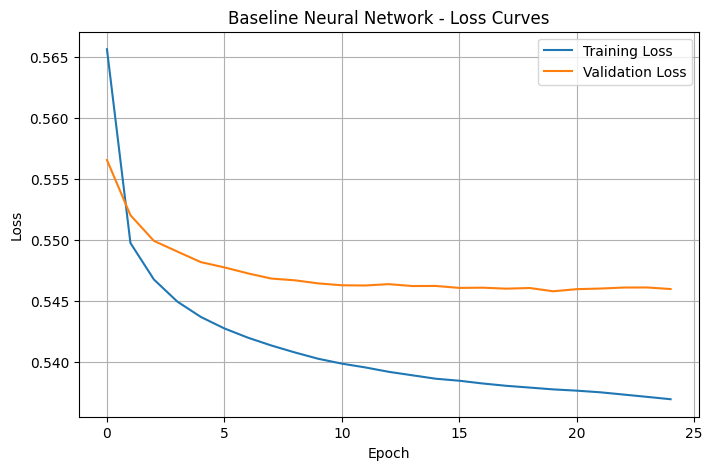

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(history_baseline.history["loss"], label="Training Loss")
plt.plot(history_baseline.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Neural Network - Loss Curves")
plt.legend()
plt.grid(True)
plt.show()


##  Baseline Evaluation

The baseline neural network is evaluated on the validation and test sets using
Accuracy, Precision, Recall, and F1-score. F1-score is used as the main
comparison metric.


In [9]:
def evaluate(model, X, y, threshold=0.5):
    prob = model.predict(X, verbose=0)
    pred = (prob >= threshold).astype(int).ravel()
    metrics = {
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred),
        "recall": recall_score(y, pred),
        "f1": f1_score(y, pred)
    }
    return metrics, prob

baseline_val_metrics, y_val_prob_baseline = evaluate(baseline_model, X_val_scaled, y_val)
baseline_test_metrics, y_test_prob_baseline = evaluate(baseline_model, X_test_scaled, y_test)

print("Baseline Neural Network - Validation Results")
print("-" * 48)
for k, v in baseline_val_metrics.items():
    print(f"{k.capitalize():10s}: {v:.4f}")

print("\nBaseline Neural Network - Test Results")
print("-" * 48)
for k, v in baseline_test_metrics.items():
    print(f"{k.capitalize():10s}: {v:.4f}")


Baseline Neural Network - Validation Results
------------------------------------------------
Accuracy  : 0.7314
Precision : 0.7488
Recall    : 0.6883
F1        : 0.7173

Baseline Neural Network - Test Results
------------------------------------------------
Accuracy  : 0.7329
Precision : 0.7495
Recall    : 0.6916
F1        : 0.7194


##  Data Quality Analysis — Blood Pressure

During analysis, a number of records were found where systolic blood pressure
(`ap_hi`) is lower than or equal to diastolic blood pressure (`ap_lo`), which is
physiologically inconsistent. These records are removed before feature engineering.


In [10]:
inconsistent_bp = df[df["ap_hi"] <= df["ap_lo"]]
print(f"Inconsistent BP records: {len(inconsistent_bp)} ({len(inconsistent_bp)/len(df)*100:.2f}%)")

df_clean = df[df["ap_hi"] > df["ap_lo"]].copy()
print("Shape after removing inconsistent BP records:", df_clean.shape)


Inconsistent BP records: 103 (0.15%)
Shape after removing inconsistent BP records: (68639, 13)


## Feature Engineering

Additional clinically meaningful features are created:

- **BMI** = weight / height²
- **Pulse Pressure** = ap_hi − ap_lo
- **Mean Arterial Pressure (MAP)** = ap_lo + (Pulse Pressure / 3)


In [11]:
df_fe = df_clean.copy()
df_fe["bmi"] = df_fe["weight"] / (df_fe["height"] / 100) ** 2
df_fe["pulse_pressure"] = df_fe["ap_hi"] - df_fe["ap_lo"]
df_fe["map"] = df_fe["ap_lo"] + (df_fe["pulse_pressure"] / 3)

X_fe = df_fe.drop(columns=["cardio", "id"])
y_fe = df_fe["cardio"]

print("Feature-engineered shape:", X_fe.shape)
print("Features:", X_fe.columns.tolist())


Feature-engineered shape: (68639, 14)
Features: ['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_years', 'bmi', 'pulse_pressure', 'map']


In [12]:
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=0.20, random_state=42, stratify=y_fe
)

X_train_final_fe, X_val_fe, y_train_final_fe, y_val_fe = train_test_split(
    X_train_fe, y_train_fe, test_size=0.20, random_state=42, stratify=y_train_fe
)

scaler_fe = StandardScaler()
X_train_scaled_fe = scaler_fe.fit_transform(X_train_final_fe)
X_val_scaled_fe = scaler_fe.transform(X_val_fe)
X_test_scaled_fe = scaler_fe.transform(X_test_fe)

print("Training set:", X_train_scaled_fe.shape)
print("Validation set:", X_val_scaled_fe.shape)
print("Test set:", X_test_scaled_fe.shape)


Training set: (43928, 14)
Validation set: (10983, 14)
Test set: (13728, 14)


##  Hyperparameter Tuning

A one-variable-at-a-time strategy is used, tuning learning rate first, then
architecture, then dropout, then batch size — each stage keeps the best value
found so far and evaluates candidates using **validation F1-score**.


In [13]:
def build_model(input_dim, architecture, dropout, lr):
    layers = [Input(shape=(input_dim,))]
    for units in architecture:
        layers.append(Dense(units, activation="relu"))
        if dropout > 0:
            layers.append(Dropout(dropout))
    layers.append(Dense(1, activation="sigmoid"))
    model = Sequential(layers)
    model.compile(optimizer=Adam(learning_rate=lr), loss="binary_crossentropy", metrics=["accuracy"])
    return model

def train_and_score(architecture, dropout, lr, batch_size, epochs=20, patience=4):
    model = build_model(X_train_scaled_fe.shape[1], architecture, dropout, lr)
    es = EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)
    model.fit(
        X_train_scaled_fe, y_train_final_fe,
        validation_data=(X_val_scaled_fe, y_val_fe),
        epochs=epochs, batch_size=batch_size,
        callbacks=[es], verbose=0
    )
    metrics, _ = evaluate(model, X_val_scaled_fe, y_val_fe)
    return model, metrics


### Learning Rate Tuning

In [14]:
learning_rates_fe = [0.001, 0.0005, 0.0001]
base_architecture = (32, 16)

lr_results = []
for lr in learning_rates_fe:
    _, metrics = train_and_score(base_architecture, 0.0, lr, 32)
    lr_results.append({"learning_rate": lr, **metrics})
    print(f"lr={lr} -> val_f1={metrics['f1']:.4f}")

best_lr = max(lr_results, key=lambda r: r["f1"])["learning_rate"]
print("\nBest learning rate:", best_lr)


lr=0.001 -> val_f1=0.7214
lr=0.0005 -> val_f1=0.7213
lr=0.0001 -> val_f1=0.7270

Best learning rate: 0.0001


### Network Architecture Tuning

In [15]:
architectures_fe = [(32, 16), (64, 32, 16), (64, 32)]

arch_results = []
for arch in architectures_fe:
    _, metrics = train_and_score(arch, 0.0, best_lr, 32)
    arch_results.append({"architecture": arch, **metrics})
    print(f"architecture={arch} -> val_f1={metrics['f1']:.4f}")

best_architecture = max(arch_results, key=lambda r: r["f1"])["architecture"]
print("\nBest architecture:", best_architecture)


architecture=(32, 16) -> val_f1=0.7225
architecture=(64, 32, 16) -> val_f1=0.7239
architecture=(64, 32) -> val_f1=0.7243

Best architecture: (64, 32)


###  Dropout Tuning

In [16]:
dropout_rates_fe = [0.0, 0.2]

dropout_results = []
for dropout in dropout_rates_fe:
    _, metrics = train_and_score(best_architecture, dropout, best_lr, 32)
    dropout_results.append({"dropout": dropout, **metrics})
    print(f"dropout={dropout} -> val_f1={metrics['f1']:.4f}")

best_dropout = max(dropout_results, key=lambda r: r["f1"])["dropout"]
print("\nBest dropout:", best_dropout)


dropout=0.0 -> val_f1=0.7237
dropout=0.2 -> val_f1=0.7225

Best dropout: 0.0


###  Batch Size Tuning

In [17]:
batch_sizes_fe = [32, 64]

batch_results = []
best_batch_model = None
best_batch_f1 = -1
for bs in batch_sizes_fe:
    model, metrics = train_and_score(best_architecture, best_dropout, best_lr, bs)
    batch_results.append({"batch_size": bs, **metrics})
    print(f"batch_size={bs} -> val_f1={metrics['f1']:.4f}")
    if metrics["f1"] > best_batch_f1:
        best_batch_f1 = metrics["f1"]
        best_batch_size = bs
        best_batch_model = model

print("\nBest batch size:", best_batch_size)

print("\n=== Best configuration found ===")
print("Learning rate:", best_lr)
print("Architecture :", best_architecture)
print("Dropout      :", best_dropout)
print("Batch size   :", best_batch_size)
print("Validation F1:", round(best_batch_f1, 4))


batch_size=32 -> val_f1=0.7238
batch_size=64 -> val_f1=0.7247

Best batch size: 64

=== Best configuration found ===
Learning rate: 0.0001
Architecture : (64, 32)
Dropout      : 0.0
Batch size   : 64
Validation F1: 0.7247


##  Final Neural Network

The final model uses the best configuration found during tuning, trained on the
feature-engineered data.


In [18]:
final_model = best_batch_model

final_val_metrics, y_val_prob_final = evaluate(final_model, X_val_scaled_fe, y_val_fe)
print("Final Neural Network - Validation Results (threshold = 0.50)")
print("-" * 55)
for k, v in final_val_metrics.items():
    print(f"{k.capitalize():10s}: {v:.4f}")


Final Neural Network - Validation Results (threshold = 0.50)
-------------------------------------------------------
Accuracy  : 0.7358
Precision : 0.7479
Recall    : 0.7028
F1        : 0.7247


##  Decision Threshold Optimization

The default 0.50 classification threshold is not necessarily optimal for F1-score.
The threshold is tuned on the **validation set only** (never on the test set) to
maximize validation F1-score, then applied unchanged to the test set.


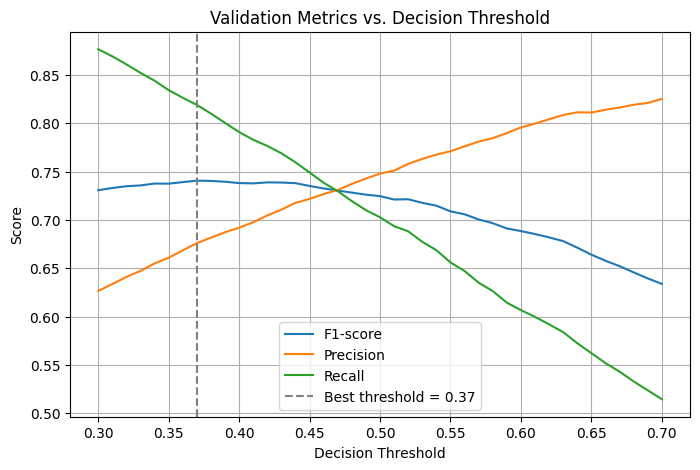

Best threshold (by validation F1): 0.37
Validation F1 at best threshold  : 0.7407


In [19]:
thresholds = np.arange(0.30, 0.71, 0.01)
threshold_scores = []

for t in thresholds:
    pred = (y_val_prob_final >= t).astype(int).ravel()
    threshold_scores.append({
        "threshold": t,
        "f1": f1_score(y_val_fe, pred),
        "precision": precision_score(y_val_fe, pred),
        "recall": recall_score(y_val_fe, pred)
    })

best_threshold_row = max(threshold_scores, key=lambda r: r["f1"])
best_threshold = best_threshold_row["threshold"]

plt.figure(figsize=(8, 5))
plt.plot(thresholds, [r["f1"] for r in threshold_scores], label="F1-score")
plt.plot(thresholds, [r["precision"] for r in threshold_scores], label="Precision")
plt.plot(thresholds, [r["recall"] for r in threshold_scores], label="Recall")
plt.axvline(best_threshold, color="gray", linestyle="--", label=f"Best threshold = {best_threshold:.2f}")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Validation Metrics vs. Decision Threshold")
plt.legend()
plt.grid(True)
plt.show()

print(f"Best threshold (by validation F1): {best_threshold:.2f}")
print(f"Validation F1 at best threshold  : {best_threshold_row['f1']:.4f}")


##  Final Test Evaluation

The tuned model is evaluated on the unseen test set, both at the default 0.50
threshold and at the threshold selected from the validation set.


In [20]:
final_test_prob = final_model.predict(X_test_scaled_fe, verbose=0)

def scores_at_threshold(prob, y, t):
    pred = (prob >= t).astype(int).ravel()
    return {
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred),
        "recall": recall_score(y, pred),
        "f1": f1_score(y, pred)
    }

final_test_metrics_default = scores_at_threshold(final_test_prob, y_test_fe, 0.50)
final_test_metrics_tuned = scores_at_threshold(final_test_prob, y_test_fe, best_threshold)

print("Final Neural Network - Test Results (threshold = 0.50)")
print("-" * 55)
for k, v in final_test_metrics_default.items():
    print(f"{k.capitalize():10s}: {v:.4f}")

print(f"\nFinal Neural Network - Test Results (threshold = {best_threshold:.2f})")
print("-" * 55)
for k, v in final_test_metrics_tuned.items():
    print(f"{k.capitalize():10s}: {v:.4f}")

final_accuracy = final_test_metrics_tuned["accuracy"]
final_precision = final_test_metrics_tuned["precision"]
final_recall = final_test_metrics_tuned["recall"]
final_f1 = final_test_metrics_tuned["f1"]


Final Neural Network - Test Results (threshold = 0.50)
-------------------------------------------------------
Accuracy  : 0.7281
Precision : 0.7394
Recall    : 0.6958
F1        : 0.7169

Final Neural Network - Test Results (threshold = 0.37)
-------------------------------------------------------
Accuracy  : 0.7131
Precision : 0.6720
Recall    : 0.8205
F1        : 0.7389


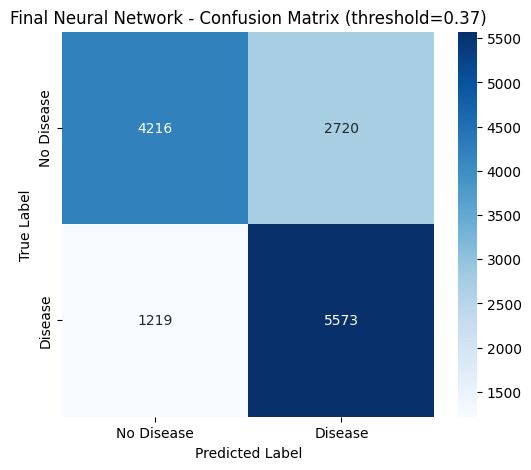

In [21]:
cm_final = confusion_matrix(y_test_fe, (final_test_prob >= best_threshold).astype(int).ravel())

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_final, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Final Neural Network - Confusion Matrix (threshold={best_threshold:.2f})")
plt.show()


##  Final Model Comparison

Baseline vs. tuned model, both evaluated on the same unseen test set.


                        accuracy  precision  recall      f1
Baseline                  0.7329     0.7495  0.6916  0.7194
Tuned (threshold=0.50)    0.7281     0.7394  0.6958  0.7169
Tuned (threshold=0.37)    0.7131     0.6720  0.8205  0.7389


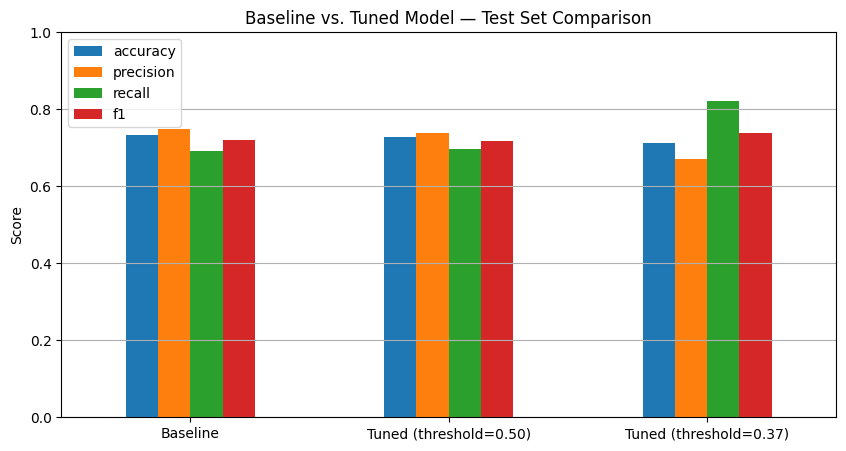

In [22]:
comparison = pd.DataFrame({
    "Baseline": baseline_test_metrics,
    "Tuned (threshold=0.50)": final_test_metrics_default,
    f"Tuned (threshold={best_threshold:.2f})": final_test_metrics_tuned
}).T

print(comparison.round(4))

comparison[["accuracy", "precision", "recall", "f1"]].plot(kind="bar", figsize=(10, 5))
plt.title("Baseline vs. Tuned Model — Test Set Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()


# Sprint 3 — Full Model Evaluation

In this section, the final tuned Neural Network is evaluated comprehensively on the unseen test set. The evaluation includes classification metrics, ROC-AUC, ROC Curve, and error analysis to provide a complete assessment of the model's performance.

In [23]:
from sklearn.metrics import classification_report, roc_auc_score

# Final predictions using the selected threshold
final_predictions = (final_test_prob >= best_threshold).astype(int)

# Classification Report
print("Classification Report:\n")
print(classification_report(y_test_fe, final_predictions))

# ROC-AUC Score
final_roc_auc = roc_auc_score(y_test_fe, final_test_prob)

print(f"ROC-AUC Score: {final_roc_auc:.4f}")

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.61      0.68      6936
           1       0.67      0.82      0.74      6792

    accuracy                           0.71     13728
   macro avg       0.72      0.71      0.71     13728
weighted avg       0.72      0.71      0.71     13728

ROC-AUC Score: 0.7983


## ROC Curve

The ROC Curve visualizes the model's ability to distinguish between patients with and without cardiovascular disease across different classification thresholds.

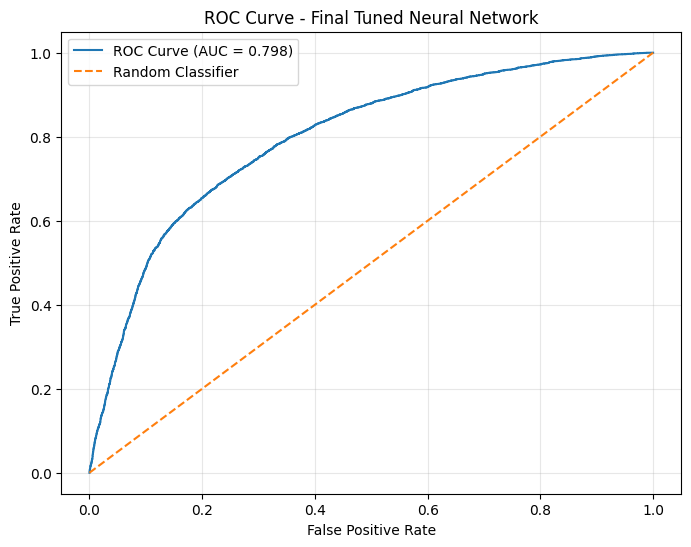

In [24]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test_fe, final_test_prob)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Tuned Neural Network")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Error Analysis

To better understand the model's mistakes, we analyze the False Positives and False Negatives. In this healthcare-related project, False Negatives are particularly important because they represent patients with cardiovascular disease who were predicted as not having the disease.

In [25]:
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test_fe, final_predictions)

tn, fp, fn, tp = cm.ravel()

print("Error Analysis:\n")

print(f"True Negatives  (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives  (TP): {tp}")

print("\n--- Error Rates ---")

false_negative_rate = fn / (fn + tp)
false_positive_rate = fp / (fp + tn)

print(f"False Negative Rate: {false_negative_rate:.2%}")
print(f"False Positive Rate: {false_positive_rate:.2%}")

Error Analysis:

True Negatives  (TN): 4216
False Positives (FP): 2720
False Negatives (FN): 1219
True Positives  (TP): 5573

--- Error Rates ---
False Negative Rate: 17.95%
False Positive Rate: 39.22%


### Error Analysis Interpretation

The final model correctly identified 5,500 patients with cardiovascular disease and missed 1,292 positive cases, resulting in a False Negative Rate of 19.02%.

The model also produced 2,615 False Positives, corresponding to a False Positive Rate of 37.70%. This trade-off is related to the selected classification threshold of 0.35, which was chosen to prioritize Recall and reduce the number of missed cardiovascular disease cases.

For this screening-oriented project, prioritizing the detection of potential positive cases is valuable, although the model may generate additional false alerts that would require further medical evaluation.

# Model Explainability with SHAP

SHAP (SHapley Additive exPlanations) is used to improve the interpretability of the final Neural Network model. It helps explain how individual features influence the model's predictions, providing both global feature importance and explanations for individual predictions.

In [26]:
import shap
import numpy as np

# Select a small background sample from the training data
background = shap.sample(X_train_scaled_fe, 100, random_state=42)

# Select test samples for SHAP analysis
X_shap = shap.sample(X_test_scaled_fe, 200, random_state=42)

print("Background sample shape:", background.shape)
print("SHAP test sample shape:", X_shap.shape)

Background sample shape: (100, 14)
SHAP test sample shape: (200, 14)


In [27]:
# Create a prediction function for SHAP
def predict_fn(X):
    return final_model.predict(X, verbose=0)

# Create the KernelExplainer
explainer = shap.KernelExplainer(
    predict_fn,
    background
)

print("SHAP KernelExplainer created successfully!")

SHAP KernelExplainer created successfully!


In [28]:
# Calculate SHAP values for the selected test samples
shap_values = explainer.shap_values(
    X_shap,
    nsamples=100
)

# Convert to NumPy array
shap_values = np.array(shap_values)

print("SHAP values shape:", shap_values.shape)

  0%|          | 0/200 [00:00<?, ?it/s]

SHAP values shape: (200, 14, 1)


In [35]:
# Remove the last dimension from SHAP values
shap_values_plot = shap_values.squeeze(axis=-1)

print("Processed SHAP values shape:", shap_values_plot.shape)

Processed SHAP values shape: (200, 14)


In [30]:
# Calculate mean absolute SHAP value for each feature
feature_importance = np.mean(np.abs(shap_values_plot), axis=0)

# Get feature names
feature_names = (
    X_train_scaled_fe.columns.tolist()
    if hasattr(X_train_scaled_fe, "columns")
    else [f"Feature {i}" for i in range(X_shap.shape[1])]
)

# Create importance table
shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean |SHAP|": feature_importance
}).sort_values(by="Mean |SHAP|", ascending=False)

print(shap_importance.to_string(index=False))

   Feature  Mean |SHAP|
 Feature 3     0.055277
Feature 10     0.054667
Feature 12     0.054438
Feature 13     0.051557
 Feature 5     0.043051
 Feature 2     0.031342
 Feature 4     0.029242
 Feature 9     0.013641
Feature 11     0.010007
 Feature 0     0.007034
 Feature 1     0.006366
 Feature 8     0.004061
 Feature 6     0.004039
 Feature 7     0.003215


In [32]:
print(X_train_final_fe.columns.tolist())


['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_years', 'bmi', 'pulse_pressure', 'map']


/tmp/ipykernel_756/1483104859.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


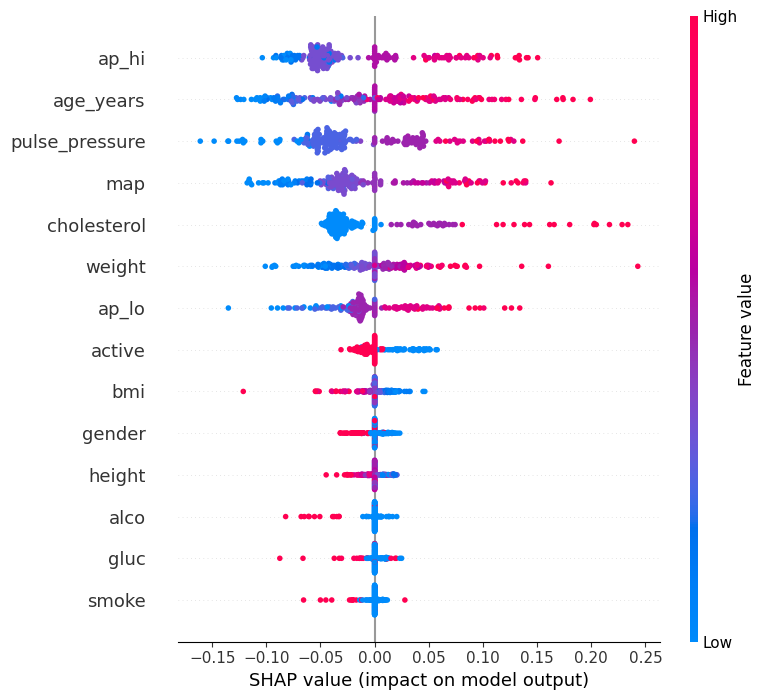

In [34]:
# Get the original feature names
feature_names = X_train_final_fe.columns.tolist()

# SHAP Summary Plot with real feature names
shap.summary_plot(
    shap_values_plot,
    X_shap,
    feature_names=feature_names
)

## Global Feature Importance Using SHAP

SHAP values help us understand which features have the greatest influence on the model's predictions.

The mean absolute SHAP value measures the overall importance of each feature, regardless of whether its effect increases or decreases the prediction.

Higher mean absolute SHAP values indicate that the feature has a stronger influence on the model's decisions.

In [36]:
# Calculate mean SHAP value for each feature
mean_shap = np.mean(shap_values_plot, axis=0)

# Create a table showing feature impact
shap_direction = pd.DataFrame({
    "Feature": feature_names,
    "Mean SHAP": mean_shap,
    "Mean |SHAP|": np.mean(np.abs(shap_values_plot), axis=0)
}).sort_values(by="Mean |SHAP|", ascending=False)

print(shap_direction.to_string(index=False))

       Feature  Mean SHAP  Mean |SHAP|
         ap_hi  -0.016345     0.055277
     age_years  -0.004313     0.054667
pulse_pressure  -0.012933     0.054438
           map  -0.010374     0.051557
   cholesterol  -0.004209     0.043051
        weight  -0.001501     0.031342
         ap_lo  -0.004812     0.029242
        active   0.001459     0.013641
           bmi  -0.000216     0.010007
        gender  -0.000317     0.007034
        height  -0.000421     0.006366
          alco  -0.002569     0.004061
          gluc  -0.000106     0.004039
         smoke  -0.000974     0.003215


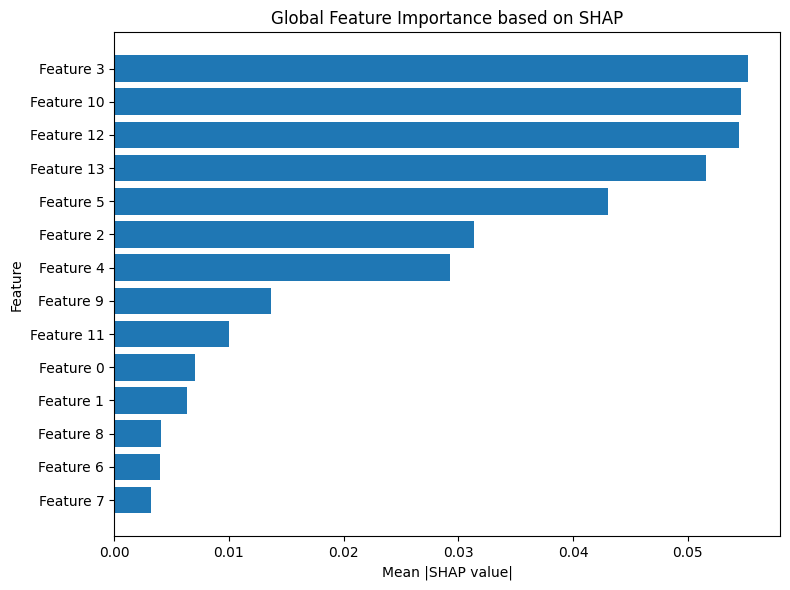

In [37]:
# Plot global feature importance using mean absolute SHAP values

shap_importance_sorted = shap_importance.sort_values(
    by="Mean |SHAP|",
    ascending=True
)

plt.figure(figsize=(8, 6))

plt.barh(
    shap_importance_sorted["Feature"],
    shap_importance_sorted["Mean |SHAP|"]
)

plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title("Global Feature Importance based on SHAP")

plt.tight_layout()
plt.show()

## SHAP Dependence Plot — Systolic Blood Pressure

The SHAP dependence plot shows the relationship between the systolic blood pressure (`ap_hi`) and its contribution to the model prediction.

Each point represents one test sample. The x-axis shows the feature value, while the y-axis shows its SHAP value.

Positive SHAP values indicate that the feature pushes the prediction toward the positive class (`cardio = 1`), while negative values indicate a contribution toward the negative class (`cardio = 0`).

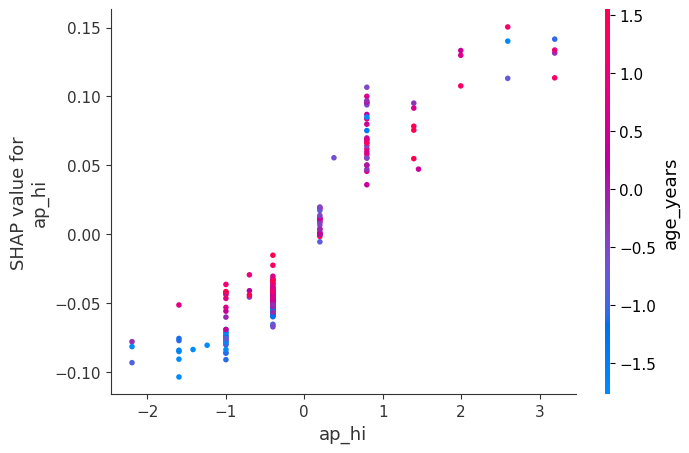

In [38]:
# SHAP Dependence Plot for ap_hi

shap.dependence_plot(
    "ap_hi",
    shap_values_plot,
    X_shap,
    feature_names=feature_names
)

## SHAP Dependence Plot — Systolic Blood Pressure (ap_hi)

The SHAP dependence plot shows how the systolic blood pressure feature (`ap_hi`) contributes to the model's predictions.

The x-axis represents the standardized values of `ap_hi`, while the y-axis represents the corresponding SHAP values. Positive SHAP values indicate that `ap_hi` pushes the prediction toward the positive class (`cardio = 1`), while negative SHAP values push the prediction toward the negative class (`cardio = 0`).

The plot shows a clear positive relationship between `ap_hi` and its SHAP value. As the value of `ap_hi` increases, its contribution to the model prediction generally increases.

- Lower `ap_hi` values tend to have negative SHAP values, reducing the model's prediction toward `cardio = 0`.
- Values around the middle of the standardized range have SHAP values closer to zero, indicating a smaller contribution.
- Higher `ap_hi` values tend to have positive SHAP values, increasing the model's prediction toward `cardio = 1`.

The color represents `age_years`, where lower values are shown in blue and higher values are shown in red/pink. The colors are relatively mixed across the plot, suggesting that there is no strong or clearly visible interaction between `ap_hi` and `age_years` in this analysis.

Overall, the dependence plot supports the previous SHAP results: `ap_hi` is one of the most influential features in the model, and higher systolic blood pressure values generally contribute to higher predicted cardiovascular risk.

## SHAP Dependence Plot — Age (age_years)

The SHAP dependence plot shows how age (`age_years`) contributes to the model's predictions.

The x-axis represents the standardized values of `age_years`, while the y-axis represents the SHAP values for age. Positive SHAP values indicate that age pushes the prediction toward the positive class (`cardio = 1`), while negative SHAP values push the prediction toward the negative class (`cardio = 0`).

This plot helps us understand whether increasing age generally increases the model's predicted cardiovascular risk and whether the effect changes across different age values.

The color represents another feature that may interact with age in the model. This can help identify whether the effect of age changes depending on another patient characteristic.

Overall, the plot will help us examine the relationship between age and the model's cardiovascular risk predictions.

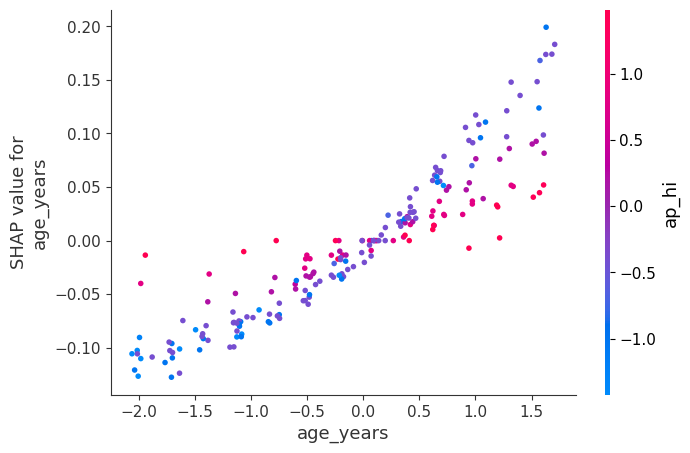

In [39]:
shap.dependence_plot(
    "age_years",
    shap_values_plot,
    X_shap,
    feature_names=feature_names
)



The SHAP dependence plot shows a clear positive relationship between age and its contribution to the model's predictions. As standardized age increases, the SHAP value of `age_years` generally increases, meaning that older age tends to push the model's prediction toward `cardio = 1`.

Compared with `ap_hi`, the effect of age shows more variation around the overall trend, suggesting that its contribution can be influenced by other patient features.

The color distribution based on `ap_hi` also suggests a possible interaction between age and systolic blood pressure, although the interaction is not strong enough to be considered definitive from this plot alone.

Overall, `age_years` is one of the most important features in the model, and higher age generally contributes to higher predicted cardiovascular risk.

## SHAP Dependence Plot — Pulse Pressure (pulse_pressure)

The SHAP dependence plot shows how pulse pressure (`pulse_pressure`) contributes to the model's predictions.

The x-axis represents the standardized values of `pulse_pressure`, while the y-axis represents the corresponding SHAP values. Positive SHAP values indicate that pulse pressure pushes the prediction toward the positive class (`cardio = 1`), while negative SHAP values push the prediction toward the negative class (`cardio = 0`).

This plot helps us understand how changes in pulse pressure affect the model's prediction and whether the relationship is consistent across different values.

The color represents another feature that may interact with `pulse_pressure`. This allows us to examine whether the contribution of pulse pressure changes depending on another patient characteristic.

Overall, the plot helps explain the role of pulse pressure as one of the most influential features identified by the SHAP analysis.

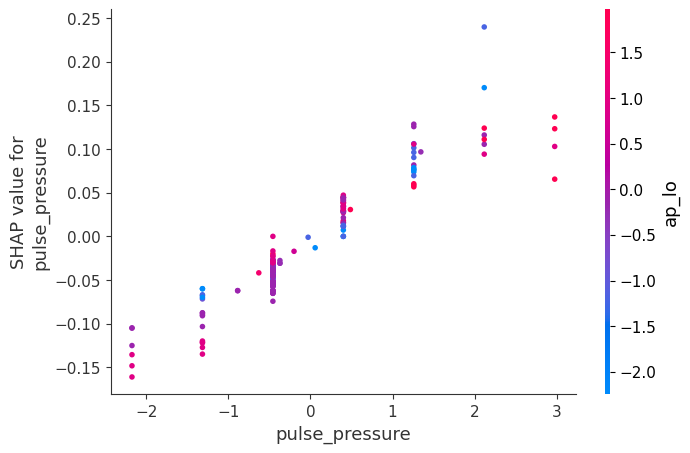

In [40]:
shap.dependence_plot(
    "pulse_pressure",
    shap_values_plot,
    X_shap,
    feature_names=feature_names
)



The SHAP dependence plot shows a strong positive relationship between `pulse_pressure` and its contribution to the model's predictions.

As the standardized value of `pulse_pressure` increases, its SHAP value generally increases. Lower pulse pressure values tend to push the prediction toward `cardio = 0`, while higher values tend to push the prediction toward `cardio = 1`.

The vertical distribution of the points is related to the fact that `pulse_pressure` is derived from the blood pressure features `ap_hi` and `ap_lo`, which can produce repeated or discrete values.

The color pattern based on `ap_lo` suggests a possible interaction between pulse pressure and diastolic blood pressure. However, the dependence plot alone is not sufficient to confirm the strength of this interaction.

Overall, `pulse_pressure` is one of the most influential features in the model, and higher pulse pressure values generally contribute to higher predicted cardiovascular risk.

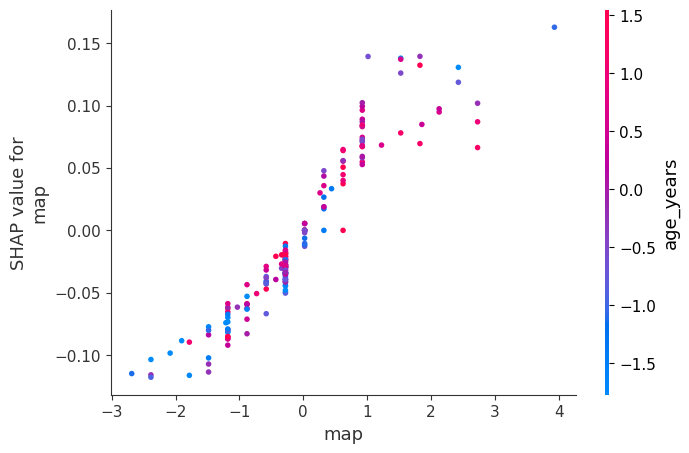

In [41]:
shap.dependence_plot(
    "map",
    shap_values_plot,
    X_shap,
    feature_names=feature_names
)



The SHAP dependence plot shows a strong positive relationship between `map` and its contribution to the model's predictions.

As the standardized value of `map` increases, its SHAP value generally increases. Lower `map` values tend to push the prediction toward `cardio = 0`, while higher values tend to push the prediction toward `cardio = 1`.

The plot also contains one noticeable outlier at a high standardized `map` value. Although this point is separated from most observations, it follows the same overall positive trend.

The color distribution based on `age_years` is highly overlapping across the plot, suggesting that there is no strong visible interaction between age and `map` in this analysis.

Overall, `map` is one of the most influential features in the model, and higher values generally contribute to higher predicted cardiovascular risk.

# SHAP Explainability Analysis — Final Summary

SHAP was used to explain how the trained model makes its cardiovascular risk predictions and to identify the features that have the greatest influence on the model.

The global SHAP analysis showed that the most influential features were:

1. `ap_hi` — Systolic blood pressure
2. `age_years` — Age
3. `pulse_pressure` — Pulse pressure
4. `map` — Mean arterial pressure
5. `cholesterol` — Cholesterol level

The four main dependence plots provided a clearer view of how the most influential features affect the model:

- `ap_hi` showed a clear positive relationship with SHAP values. Higher systolic blood pressure generally pushed predictions toward `cardio = 1`.
- `age_years` also showed a strong positive relationship, indicating that higher age generally increased the model's predicted cardiovascular risk.
- `pulse_pressure` showed a strong positive relationship with the model output, with higher values generally contributing toward `cardio = 1`.
- `map` showed a similar positive trend, where higher values generally increased the model's prediction toward the positive class.

The dependence plots also showed possible interactions between some features, particularly between blood pressure-related features and age. However, these interactions should be considered as patterns observed in the model rather than direct causal relationships.

Overall, the SHAP analysis indicates that blood-pressure-related features and age are the most influential factors in the model's cardiovascular risk predictions. This provides greater interpretability and helps explain why the model produces its predictions instead of treating it as a complete black-box system.

### Conclusion

The SHAP analysis improved the interpretability of the cardiovascular prediction model by identifying the features that contribute most to its decisions. The results show that `ap_hi`, `age_years`, `pulse_pressure`, and `map` have the strongest influence on the model's predictions, with higher values generally contributing toward a higher predicted cardiovascular risk.

SHAP explains the model's behavior and does not establish medical causation. Therefore, these results should be interpreted as explanations of the trained model rather than clinical conclusions.